### Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [1]:
from google.colab import drive
import os

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'

os.makedirs(PROJECT_DIR, exist_ok=True)

### Step 2: Download the Dataset
Since the file is huge, you can download it using `wget`.
*Note: Replace `DIRECT_DOWNLOAD_URL_HERE` with the actual download link from the DIMO website.*

In [11]:
TAR_PATH = os.path.join(PROJECT_DIR, "dimo.tar")

In [12]:
DATASET_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo.tar"


# Download only if it doesn't exist yet
if not os.path.exists(TAR_PATH):
    !wget -O "{TAR_PATH}" "{DATASET_URL}"

--2026-05-27 19:20:14--  https://datasets.ilabt.imec.be/dimo/tar/dimo.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14153728 (13M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’

/content/drive/MyDr 100%[===================>]  13.50M  5.44MB/s    in 2.5s    

2026-05-27 19:20:18 (5.44 MB/s) - ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’ saved [14153728/14153728]



### Step 3: Extract a Small Subset & Visualize
Instead of unzipping 64GB, let's peek into the zip file, find the first 5 images, extract only them, and visualize. This saves massive amounts of time and disk space.

In [13]:
import tarfile
import matplotlib.pyplot as plt
from PIL import Image
import io
import os

def visualize_subset_from_tar(tar_filepath, num_images=4):
    if not os.path.exists(tar_filepath):
        print(f"File not found: {tar_filepath}")
        return

    # Open the tar file without extracting everything
    with tarfile.open(tar_filepath, 'r') as tar:
        # Get a list of all members (files) in the tar
        members = tar.getmembers()

        # Filter for image files (assuming jpg or png)
        image_members = [m for m in members if m.name.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Total images found in archive: {len(image_members)}")

        if not image_members:
            print("No images found. This archive might just contain annotations or base directories.")
            return

        # Select a few images
        selected_members = image_members[:num_images]

        # Plotting
        fig, axes = plt.subplots(1, len(selected_members), figsize=(15, 5))
        if len(selected_members) == 1:
            axes = [axes]

        for ax, member in zip(axes, selected_members):
            # Extract the single image to memory
            f = tar.extractfile(member)
            if f is not None:
                img = Image.open(io.BytesIO(f.read()))
                ax.imshow(img)
                ax.set_title(member.name.split('/')[-1])
                ax.axis('off')
        plt.tight_layout()
        plt.show()

In [14]:
visualize_subset_from_tar(TAR_PATH, num_images=4)

Total images found in archive: 0
No images found. This archive might just contain annotations or base directories.


### Step 4: Unpack and inspect the Base archive

In [ ]:
import tarfile

# Extract the base archive
base_extract_path = os.path.join(PROJECT_DIR, 'dimo_extracted')
os.makedirs(base_extract_path, exist_ok=True)

print(f"Extracting base archive to {base_extract_path}...")
with tarfile.open(TAR_PATH, 'r') as tar:
    tar.extractall(path=base_extract_path)

In [16]:
# List the extracted structure (up to a certain depth or just the top directories)
for root, dirs, files in os.walk(base_extract_path):
    level = root.replace(base_extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:15]: # Show max 5 files per directory to keep output clean
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files)-5} more files")

Extracting base archive to /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_extracted...


/tmp/ipykernel_2100/3010695396.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=base_extract_path)


dimo_extracted/
    ._dimo
    dimo/
        ._.DS_Store
        .DS_Store
        ._CHANGELOG.md
        CHANGELOG.md
        ._models
        models/
            .DS_Store
            ._obj_000002.ply
            obj_000002.ply
            ._obj_000003.ply
            obj_000003.ply
            ._models_info.json
            models_info.json
            ._obj_000001.ply
            obj_000001.ply
            ._obj_000004.ply
            obj_000004.ply
            ._obj_000005.ply
            obj_000005.ply
            ._obj_000006.ply
            obj_000006.ply
            ... and 11 more files
            construction/
                000003.step
                000002.step
                000005.step
                000004.step
                000006.step
                000005.pdf
                ._000004.pdf
                000004.pdf
                ._000001.step
                000001.step
                ._000006.pdf
                000006.pdf
                000003.pdf
      

### Step 5: Download Real-World Data (RealSense D415)
Since the project involves comparing real and synthetic data, let's start with the smallest real-world image archive (RealSense D415, 12.7 GB). Replace the URL below with the actual link to this archive.

In [17]:
# Replace with the actual URL for RealSense D415 from the DIMO website
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "real_d415.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

--2026-05-27 19:29:34--  https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12715229696 (12G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/real_d415.tar’

/content/drive/MyDr   8%[>                   ]   1.00G  13.7MB/s    in 1m 59s  

2026-05-27 19:31:35 (8.63 MB/s) - Connection closed at byte 1078341713. Retrying.

--2026-05-27 19:31:36--  (try: 2)  https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 12715229696 (12G), 11636887983 (11G) remaining [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/

Total images found in archive: 15600


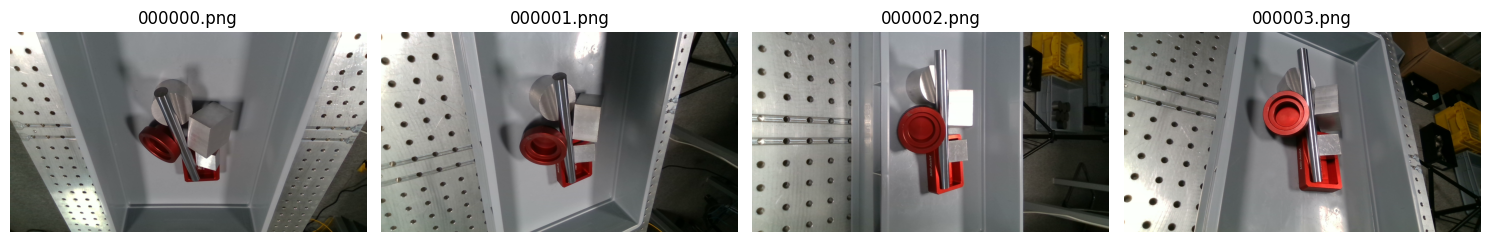

In [18]:
# Once downloaded, you can visualize a few images from it directly!
visualize_subset_from_tar(REAL_TAR_PATH, num_images=4)

In [21]:
import tarfile

base_extract_path = "/content/real_d415"
os.makedirs(base_extract_path, exist_ok=True)

print(f"Extracting base archive to {base_extract_path}...")
with tarfile.open(REAL_TAR_PATH, 'r') as tar:
    tar.extractall(path=base_extract_path)

Extracting base archive to /content/real_d415...


/tmp/ipykernel_2100/4028177766.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=base_extract_path)


In [23]:
# List the extracted structure (up to a certain depth or just the top directories)
for root, dirs, files in os.walk(base_extract_path):
    level = root.replace(base_extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:15]: # Show max 5 files per directory to keep output clean
        print(f"{subindent}{f}")
    if len(files) > 15:
        print(f"{subindent}... and {len(files)-15} more files")

real_d415/
    real_d415/
        000300/
            scene_info.json
            scene_gt.json
            scene_camera.json
            scene_gt_world.json
            rgb/
                000004.png
                000001.png
                000009.png
                000005.png
                000010.png
                000006.png
                000012.png
                000003.png
                000000.png
                000011.png
                000008.png
                000007.png
                000002.png
            depth/
                000004.png
                000001.png
                000009.png
                000005.png
                000010.png
                000006.png
                000012.png
                000003.png
                000000.png
                000011.png
                000008.png
                000007.png
                000002.png
        000432/
            scene_info.json
            scene_gt.json
            scene_camera.json
    